# Module 1 Topic 3 Practical — Classification

This practical connects image features, class labels and linear decision boundaries. You will use a perceptron for hard class decisions, then connect logistic regression's linear score to sigmoid probabilities and binary cross-entropy.

## Official implementation guides

These optional official guides connect this topic's concepts to standard Python implementations and the practical work. They are not required for assessment.

- [`Perceptron` reference](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html) — see how a linear classifier is fitted and used for prediction.
- [Classification metrics guide](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics) — connect predictions to accuracy, precision, recall and related measures.
- [`ConfusionMatrixDisplay` reference](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) — visualise correct and incorrect class predictions.
- [`LogisticRegression` reference](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) — fit a linear probabilistic classifier and inspect decision scores and probabilities.
- [`log_loss` reference](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html) — evaluate predicted probabilities using cross-entropy.


## Learning outcomes

By the end of this practical, you should be able to:

- explain how a 28 × 28 image becomes 784 numerical features;
- create binary and multiclass target labels;
- fit a perceptron and interpret its decision score;
- explain one-vs-rest multiclass prediction;
- use baselines, confusion matrices and errors to describe behaviour;
- connect a logistic-regression score, sigmoid probability and binary cross-entropy; and
- implement and interpret one logistic-regression gradient update.

### Good habits used in this notebook

- Inspect examples and label definitions before fitting.
- Keep the official training and test sets separate.
- Compare accuracy with a majority-class baseline.
- Inspect confusion patterns and individual errors, not only one score.

These habits support the topic; they are not separate programming exercises.

### If Python is new to you

- Run the notebook from top to bottom because later cells use variables created earlier.
- Begin with the short `TODO` completions, then use the completed earlier cells as patterns for the larger coding challenge.
- Read the input and expected output described above each code cell before writing code.
- Build the challenge one step at a time and run the cell after each small section.
- Ask a tutor about the first error message before changing unrelated code.
- To write an explanation, double-click the Markdown cell labelled **Write your answer**, replace the prompt, and run the cell.

The practical is designed for a two-hour session. The core student-written and adapted coding should take approximately **45–60 minutes**; interpretation and discussion are additional to that coding time.

## Setup

The first run downloads MNIST and may take several minutes. If this download fails in class, ask the tutor for the locally cached copy.

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, log_loss, precision_score, recall_score
)

RANDOM_STATE = 42

def plot_digit(image_data, axis=None):
    if axis is None:
        axis = plt.gca()
    axis.imshow(image_data.reshape(28, 28), cmap="binary", interpolation="nearest")
    axis.axis("off")

mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data.astype(np.float32) / 255.0
y = np.asarray(mnist.target).astype(str)
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print("Training:", X_train.shape, "Test:", X_test.shape)
print("One image has", X_train.shape[1], "features")

Training: (60000, 784) Test: (10000, 784)
One image has 784 features


## Question 1 — From images to features

Complete the two marked lines to display two examples for each digit. Then describe within-class variation, likely confusions, and what one feature represents.

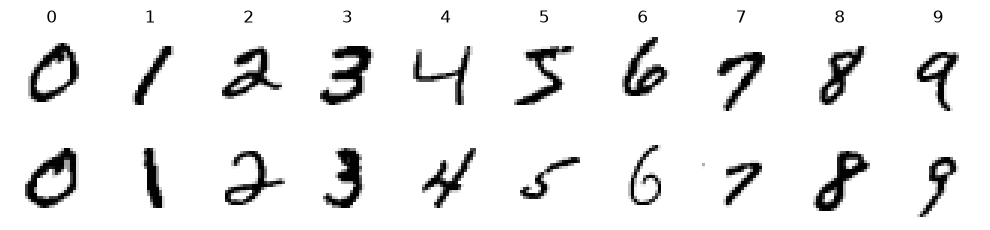

In [ ]:
fig, axes = plt.subplots(2, 10, figsize=(10, 2.6))
for digit in range(10):
    digit_indices = np.flatnonzero(y_train == str(digit))
    for row in range(2):
        # TODO 1: choose the row-th index from digit_indices.
        image_index = digit_indices[row]
        # TODO 2: plot that image on axes[row, digit].
        plot_digit(X_train[image_index], axes[row, digit])
        if row == 0:
            axes[row, digit].set_title(str(digit))
plt.tight_layout(); plt.show()

### Write your answer — Question 1

This code shows two examples of every digit from 0 to 9 from the MNIST training dataset. Since everyone writes numbers differently, the same digit can have variation. Some digits can also be similar to another. Also, since each image is 28*28 pixels, it has 784 features. One feature represents the intensity of one pixel at a particular position in the image. Since the pixel values were divided by 255 (X = mnist.data.astype(np.float32) / 255.0), each feature has a value between 0 and 1.

## Question 2 — Binary perceptron: is this digit a 5?

Create Boolean training labels and fit the supplied perceptron. The test labels and evaluation are supplied.

In [13]:
# TODO 3: True where the training digit is 5.
y_train_5 = (y_train == "5")
y_test_5 = (y_test == "5")
binary_perceptron = Perceptron(random_state=RANDOM_STATE)
# TODO 4: fit the perceptron using X_train and y_train_5.
binary_perceptron.fit(X_train, y_train_5)

binary_pred = binary_perceptron.predict(X_test)
binary_score = binary_perceptron.decision_function(X_test)
print("Majority baseline:", max(y_test_5.mean(), 1-y_test_5.mean()))
print("Test accuracy:", accuracy_score(y_test_5, binary_pred))
print("First five scores:", np.round(binary_score[:5], 2))

Majority baseline: 0.9108
Test accuracy: 0.9651
First five scores: [-213.39  -56.32  -49.   -223.95 -226.69]


### Write your answer — Question 2

Here, the problem becomes a binary classification. If it is true, the image is a 5, while false gives any other number. The majority baseline is 0.9108 while test accuracy is 0.9651 for the perception. For the decision score, a positive score predicts 5 and a negative score predicts not 5. the size of the score shows how far the example is from the boundary, not it's probability.

## Question 3 — Four-class one-vs-rest classification

The target groups digits 2, 4 and 6 separately and combines all remaining digits as `others`. Complete the fit line, then use the supplied confusion matrix.

Majority baseline: 0.7028
Test accuracy: 0.9311


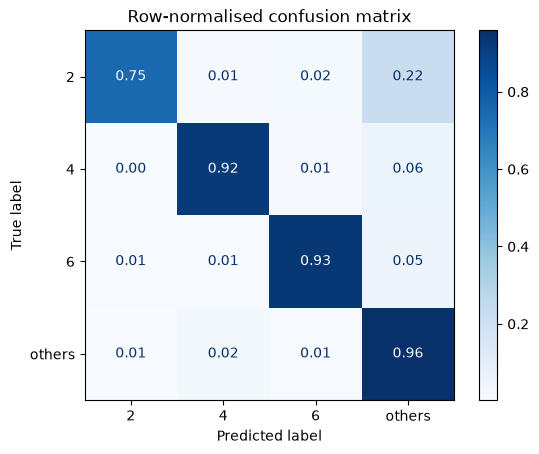

In [14]:
selected_digits = ["2", "4", "6"]
y_train_4 = np.where(np.isin(y_train, selected_digits), y_train, "others")
y_test_4 = np.where(np.isin(y_test, selected_digits), y_test, "others")

multi = Perceptron(random_state=RANDOM_STATE)
# TODO 5: fit using the training images and four-class target.
multi.fit(X_train, y_train_4)
multi_pred = multi.predict(X_test)

order = ["2", "4", "6", "others"]
print("Majority baseline:", np.mean(y_test_4 == "others"))
print("Test accuracy:", accuracy_score(y_test_4, multi_pred))
ConfusionMatrixDisplay.from_predictions(
    y_test_4, multi_pred, labels=order, normalize="true",
    cmap="Blues", values_format=".2f"
)
plt.title("Row-normalised confusion matrix")
plt.show()

### Write your answer — Question 3

The majority baseline is about 0.7028 since most test images belong to the others class. The test accuracy is 0.9311, so it performs better than the baseline. From the Row-normalised confusion matrix, 2 is the hardest to classify with 75% classified correctly while 22% are classified as others. 4 and 6 are classified correctly about 92% and 93% of the time, while others is correct about 96% of the time. 

## Question 4 — From a hard decision to a probability

The perceptron and logistic regression both form a linear score, but they use it differently. The perceptron makes a hard class decision; logistic regression passes the score through the sigmoid function and estimates a probability.

Complete the code to:

1. fit logistic regression for the existing “is this digit a 5?” target;
2. compare its accuracy, precision, recall and log loss with the perceptron;
3. verify that applying the sigmoid to `decision_function` reproduces `predict_proba`; and
4. perform one logistic-regression gradient update on a tiny dataset and check whether binary cross-entropy decreases; and
5. inspect the resulting two-feature linear decision boundary.

The logistic model uses 15,000 training images to keep classroom runtime reasonable; it is still evaluated on the same untouched test set.

,model,accuracy,precision,recall,log_loss
0,Perceptron,0.9651,0.9010,0.6839,0.8440
1,Logistic regression,0.9744,0.8888,0.8150,0.0919


Largest |sigmoid(score) - predict_proba|: 0.0


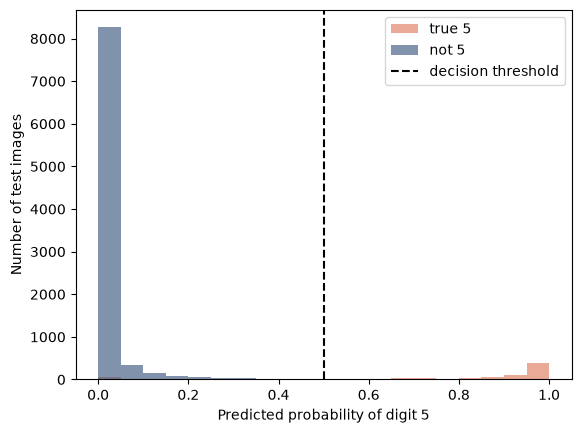

Gradient for w: [-0.75   -0.5625]
Gradient for b: 0.0
BCE before update: 0.6931
BCE after update: 0.3538


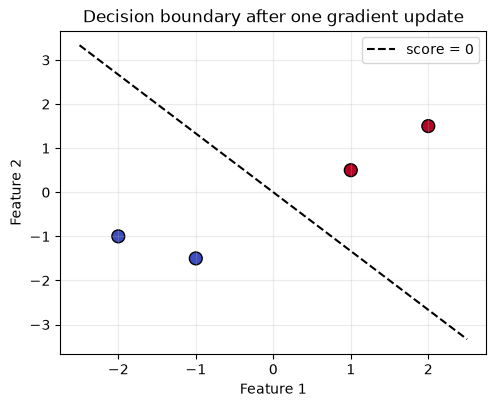

In [15]:
# Part A: compare a perceptron with logistic regression for “is this a 5?”.
logistic_train_size = 15_000
logistic_model = LogisticRegression(
    solver="liblinear", max_iter=300, random_state=RANDOM_STATE
)
# TODO 6: fit on the first logistic_train_size images and binary targets.
logistic_model.fit(X_train[:logistic_train_size], y_train_5[:logistic_train_size])

# TODO 7: obtain positive-class probabilities and threshold them at 0.5.
logistic_probability = logistic_model.predict_proba(X_test)[:, 1]
logistic_prediction = (logistic_probability >= 0.5)

# A sigmoid is applied to the perceptron score only to demonstrate why
# “between 0 and 1” does not automatically mean a calibrated probability.
perceptron_probability = 1 / (1 + np.exp(-np.clip(binary_score, -50, 50)))

comparison = pd.DataFrame([
    {
        "model": "Perceptron",
        "accuracy": accuracy_score(y_test_5, binary_pred),
        "precision": precision_score(y_test_5, binary_pred, zero_division=0),
        "recall": recall_score(y_test_5, binary_pred, zero_division=0),
        "log_loss": log_loss(y_test_5, perceptron_probability),
    },
    {
        "model": "Logistic regression",
        # TODO 8: complete all four metrics.
        "accuracy": accuracy_score(y_test_5, logistic_prediction),
        "precision": precision_score(y_test_5, logistic_prediction, zero_division=0),
        "recall": recall_score(y_test_5, logistic_prediction, zero_division=0),
        "log_loss": log_loss(y_test_5, logistic_probability),
    },
])
display(comparison.round(4))

# TODO 9: apply the sigmoid to logistic regression's decision score.
score_probability = 1 / (1 + np.exp(-logistic_model.decision_function(X_test)))
print(
    "Largest |sigmoid(score) - predict_proba|:",
    np.max(np.abs(score_probability - logistic_probability)),
)

plt.hist(
    logistic_probability[y_test_5], bins=20, alpha=0.65,
    label="true 5", color="#E07A5F"
)
plt.hist(
    logistic_probability[~y_test_5], bins=20, alpha=0.65,
    label="not 5", color="#3D5A80"
)
plt.axvline(0.5, color="black", linestyle="--", label="decision threshold")
plt.xlabel("Predicted probability of digit 5")
plt.ylabel("Number of test images")
plt.legend()
plt.show()


# Part B: one manual gradient update for logistic regression.
X_toy = np.array([[-2.0, -1.0], [-1.0, -1.5], [1.0, 0.5], [2.0, 1.5]])
y_toy = np.array([0.0, 0.0, 1.0, 1.0])
w = np.zeros(X_toy.shape[1])
b = 0.0
learning_rate = 0.5

def sigmoid_stable(values):
    return 1 / (1 + np.exp(-np.clip(values, -50, 50)))

probability_before = sigmoid_stable(X_toy @ w + b)
loss_before = log_loss(y_toy, probability_before)

# TODO 10: calculate the gradients of mean binary cross-entropy.
gradient_w = X_toy.T @ (probability_before - y_toy) / len(y_toy)
gradient_b = np.mean(probability_before - y_toy)

# TODO 11: update w and b by subtracting learning_rate × gradient.
w = w - learning_rate * gradient_w
b = b - learning_rate * gradient_b
probability_after = sigmoid_stable(X_toy @ w + b)
loss_after = log_loss(y_toy, probability_after)

print("Gradient for w:", np.round(gradient_w, 4))
print("Gradient for b:", round(gradient_b, 4))
print("BCE before update:", round(loss_before, 4))
print("BCE after update:", round(loss_after, 4))


# The boundary contains points whose updated linear score is zero:
# w[0] * x1 + w[1] * x2 + b = 0.
x1_boundary = np.linspace(X_toy[:, 0].min() - 0.5, X_toy[:, 0].max() + 0.5, 100)
x2_boundary = -(w[0] * x1_boundary + b) / w[1]

plt.figure(figsize=(5.5, 4.2))
plt.scatter(
    X_toy[:, 0], X_toy[:, 1], c=y_toy,
    cmap="coolwarm", edgecolor="black", s=85
)
plt.plot(x1_boundary, x2_boundary, color="black", linestyle="--", label="score = 0")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision boundary after one gradient update")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


### Write your answer — Question 4

The perceptron gets about 0.9651 accuracy, 0.9010 precision and 0.6839 recall. Logistic regression gets about 0.9744 accuracy, 0.8888 precision and 0.8150 recall. Logistic regression performed slightly better overall than the perceptron. It had higher accuracy and recall. This means it correctly classified more images and found more of the actual 5s. The perceptron had slightly better precision, meaning that when it predicted a 5, it was often correct. Logistic regression also had a much lower log loss, showing that its probability predictions were more reliable. It calculates a score using the input features and then uses the sigmoid function to turn that score into a value between 0 and 1. If the probability is above 0.5, the model predicts a 5; otherwise, it predicts not 5. The perceptron is mainly designed to make a yes-or-no classification, so applying sigmoid to its score does not make it a reliable probability. 

## Final reflection

For a real document-recognition system, what data shift or error cost might matter beyond this test accuracy?

### Write your answer — Final reflection

A real document-recognition system could face data that looks different from the training data. For example, handwriting styles, image quality, lighting, scanning noise etc. could reduce performance. The cost of errors can also be different depending on the situation. Misreading important digit  like an account number, identification number or form may create more issues. Because of this, a real system should consider the types of mistakes it makes instead of only focusing on test accuracy.

## Optional extensions

These are not required. Use them only after completing the core work:

- Repeat the perceptron/logistic comparison for another target digit.
- Change the toy learning rate and identify values that reduce or increase the loss.

## Summary

This practical connected the week’s ideas:

- images become numerical feature vectors;
- the target definition determines the classification problem;
- perceptrons and logistic regression form linear decision boundaries;
- logistic regression connects a score, sigmoid probability and binary cross-entropy;
- one-vs-rest extends binary classification to several classes; and
- baselines, class-specific metrics and error inspection reveal more than accuracy alone.